## Test

The same feature definitions used during training are reconstructed for the
unseen data, and the scaler fitted during training is used to transform the
features.

Only the features selected during training are retained:

$$
\widetilde{\Theta}_{\mathrm{active}}
=
\widetilde{\Theta}
[:,\mathrm{active\_indices}]
$$

The learned coefficients are then applied to obtain the one-dimensional
representation:

$$
\boxed{
u_{\mathrm{unseen}}
=
\widetilde{\Theta}_{\mathrm{unseen,active}}c
}
$$

The resulting $u_{\mathrm{unseen}}$ is then compared with the corresponding
target $y_{\mathrm{unseen}}$ to evaluate whether the learned representation
generalises beyond the training data.

The primary information-theoretic metric is the mutual information:

$$
I(u_{\mathrm{unseen}}, y_{\mathrm{unseen}})
$$

The $u$-$y$ relationship is also visualised using a scatter plot.

A successful model should therefore satisfy both:

$$
I(u_{\mathrm{unseen}}, y_{\mathrm{unseen}})
\text{ remains high}
$$

and

$$
y_{\mathrm{unseen}} \approx f(u_{\mathrm{unseen}})
$$

with the unseen samples following a stable relationship. However, the fitting of function f is not within the scope of this notebook.

### Results

This section is used for testing model and visualise the result for current 10-parameter tests.

In [1]:
import sys
import os
import pickle
import numpy as np

sys.path.insert(0, os.path.abspath(".."))
from src.evaluation import build_theta_from_model, visualize_sparse_prediction, analyze_feature_cmi, analyze_feature_importance
from src.sparse_interp import sparse_ee_interpretation, save_sparse_result, load_sparse_result, sparse_predict
from src.function_library import build_function_library, select_top_power_features, power_features, build_power_library

In [2]:
# loading data
data = np.load(r"D:\Law\25-26\research intern\final_data.npz")
print(data.files)

X_final = data["param"]

param_names = [
    "C_p",
    "Za_p",
    "R_p",
    "Emax_rv",
    "Emin_rv",
    "C_s",
    "Za_s",
    "R_s",
    "Emax_lv",
    "Emin_lv"
]

v_lv_final = data["v_lv"]
v_rv_final = data["v_rv"]

y_v_lv_max_final = np.max(v_lv_final, axis=1)
y_v_lv_min_final = np.min(v_lv_final, axis=1)

y_v_rv_max_final = np.max(v_rv_final, axis=1)
y_v_rv_min_final = np.min(v_rv_final, axis=1)

y_v_lv_mean_final = np.mean(v_lv_final, axis=1)
y_v_rv_mean_final = np.mean(v_rv_final, axis=1)

['p_lv', 'p_rv', 'p_pa', 'v_lv', 'v_rv', 'q_av', 'q_mv', 'q_pv', 'param']


In [3]:
# load old sampling
with open("../notebook/final_data_split.pkl", "rb") as f:
    final_data_split = pickle.load(f)

final_train_idx = final_data_split["train_idx"]
final_test_idx = final_data_split["test_idx"]

X_final_train = X_final[final_train_idx]
X_final_test = X_final[final_test_idx]

y_v_lv_max_final_train = y_v_lv_max_final[final_train_idx]
y_v_lv_max_final_test = y_v_lv_max_final[final_test_idx]

y_v_lv_min_final_train = y_v_lv_min_final[final_train_idx]
y_v_lv_min_final_test = y_v_lv_min_final[final_test_idx]

y_v_rv_max_final_train = y_v_rv_max_final[final_train_idx]
y_v_rv_max_final_test = y_v_rv_max_final[final_test_idx]

y_v_rv_min_final_train = y_v_rv_min_final[final_train_idx]
y_v_rv_min_final_test = y_v_rv_min_final[final_test_idx]

y_v_lv_mean_final_train = y_v_lv_mean_final[final_train_idx]
y_v_rv_mean_final_train = y_v_rv_mean_final[final_train_idx]

y_v_lv_mean_final_test = y_v_lv_mean_final[final_test_idx]
y_v_rv_mean_final_test = y_v_rv_mean_final[final_test_idx]

In [4]:
sparse_result_v_lv_max_final = load_sparse_result("../results/sparse_result_v_lv_max_final.pkl")


sparse_result_v_lv_min_final = load_sparse_result(
    "../results/sparse_result_v_lv_min_final.pkl"
)

sparse_result_v_rv_max_final = load_sparse_result(
    "../results/sparse_result_v_rv_max_final.pkl"
)

sparse_result_v_rv_min_final = load_sparse_result(
    "../results/sparse_result_v_rv_min_final.pkl"
)

sparse_result_v_lv_mean_final = load_sparse_result(
    "../results/sparse_result_v_lv_mean_final.pkl"
)

sparse_result_v_rv_mean_final = load_sparse_result(
    "../results/sparse_result_v_rv_mean_final.pkl"
)

Loaded from ../results/sparse_result_v_lv_max_final.pkl
MI = 1.844425
Active features = 50
Loaded from ../results/sparse_result_v_lv_min_final.pkl
MI = 1.254707
Active features = 2
Loaded from ../results/sparse_result_v_rv_max_final.pkl
MI = 1.946094
Active features = 75
Loaded from ../results/sparse_result_v_rv_min_final.pkl
MI = 1.374533
Active features = 17
Loaded from ../results/sparse_result_v_lv_mean_final.pkl
MI = 1.889857
Active features = 49
Loaded from ../results/sparse_result_v_rv_mean_final.pkl
MI = 1.805774
Active features = 28


### Visualisation

MI          : 1.946596


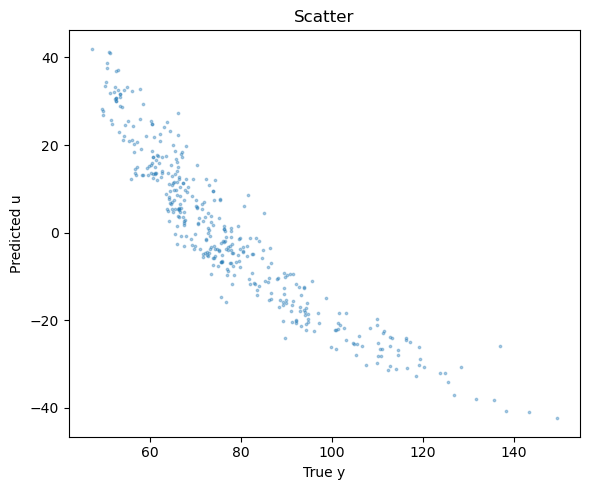

In [24]:
Theta_full_v_lv_max_final = build_theta_from_model(
    X_final_test,
    sparse_result_v_lv_max_final,
    param_names,
)

Theta_full_scaled_v_lv_max_final = (
    sparse_result_v_lv_max_final["scaler"].transform(
        Theta_full_v_lv_max_final
    )
)

Theta_scaled_v_lv_max_final = (
    Theta_full_scaled_v_lv_max_final[
        :,
        sparse_result_v_lv_max_final["active_indices"]
    ]
)

u_v_lv_max_final_test = visualize_sparse_prediction(
    Theta_scaled_v_lv_max_final,
    y_v_lv_max_final_test,
    "../results/sparse_result_v_lv_max_final.pkl",
)

MI          : 1.518417


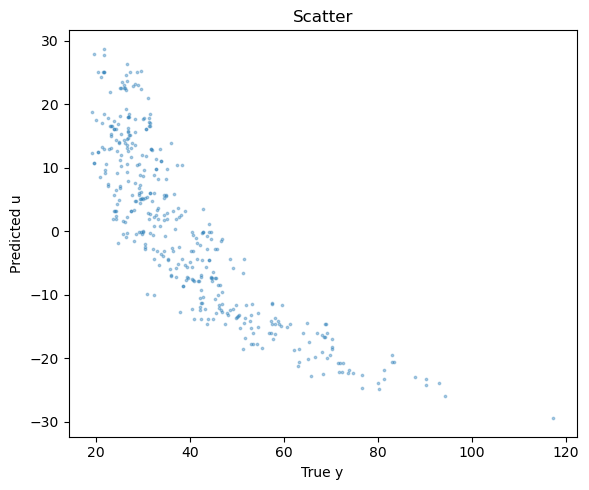

In [25]:
Theta_full_v_lv_min_final = build_theta_from_model(
    X_final_test,
    sparse_result_v_lv_min_final,
    param_names,
)

Theta_full_scaled_v_lv_min_final = (
    sparse_result_v_lv_min_final["scaler"].transform(
        Theta_full_v_lv_min_final
    )
)

Theta_scaled_v_lv_min_final = (
    Theta_full_scaled_v_lv_min_final[
        :,
        sparse_result_v_lv_min_final["active_indices"]
    ]
)

u_v_lv_min_final_test = visualize_sparse_prediction(
    Theta_scaled_v_lv_min_final,
    y_v_lv_min_final_test,
    "../results/sparse_result_v_lv_min_final.pkl",
)

MI          : 1.935376


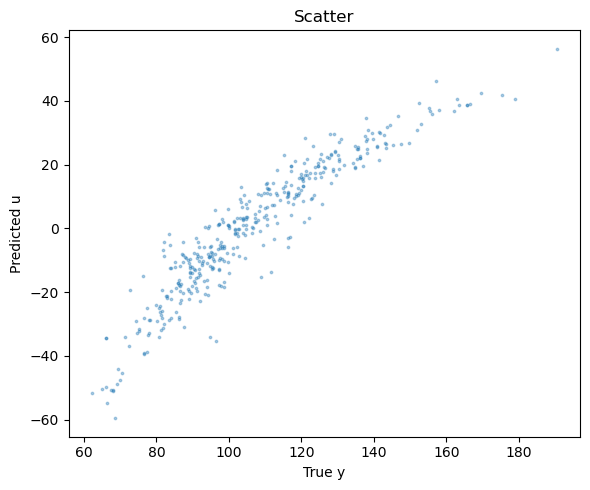

In [26]:

Theta_full_v_rv_max_final = build_theta_from_model(
    X_final_test,
    sparse_result_v_rv_max_final,
    param_names,
)

Theta_full_scaled_v_rv_max_final = (
    sparse_result_v_rv_max_final["scaler"].transform(
        Theta_full_v_rv_max_final
    )
)

Theta_scaled_v_rv_max_final = (
    Theta_full_scaled_v_rv_max_final[
        :,
        sparse_result_v_rv_max_final["active_indices"]
    ]
)

u_v_rv_max_final_test = visualize_sparse_prediction(
    Theta_scaled_v_rv_max_final,
    y_v_rv_max_final_test,
    "../results/sparse_result_v_rv_max_final.pkl",
)

MI          : 1.565676


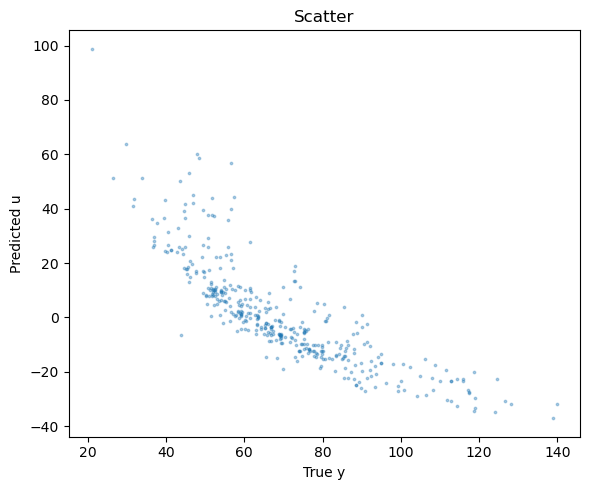

In [27]:


Theta_full_v_rv_min_final = build_theta_from_model(
    X_final_test,
    sparse_result_v_rv_min_final,
    param_names,
)

Theta_full_scaled_v_rv_min_final = (
    sparse_result_v_rv_min_final["scaler"].transform(
        Theta_full_v_rv_min_final
    )
)

Theta_scaled_v_rv_min_final = (
    Theta_full_scaled_v_rv_min_final[
        :,
        sparse_result_v_rv_min_final["active_indices"]
    ]
)

u_v_rv_min_final_test = visualize_sparse_prediction(
    Theta_scaled_v_rv_min_final,
    y_v_rv_min_final_test,
    "../results/sparse_result_v_rv_min_final.pkl",
)

MI          : 2.013851


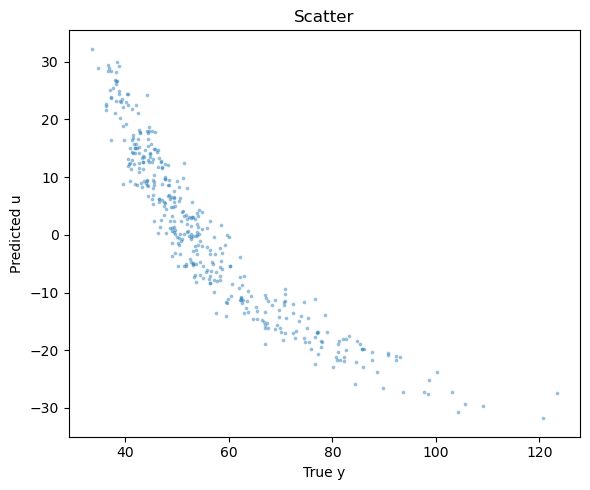

In [33]:
Theta_full_v_lv_mean_final = build_theta_from_model(
    X_final_test,
    sparse_result_v_lv_mean_final,
    param_names,
)

Theta_full_scaled_v_lv_mean_final = (
    sparse_result_v_lv_mean_final["scaler"].transform(
        Theta_full_v_lv_mean_final
    )
)

Theta_scaled_v_lv_mean_final = (
    Theta_full_scaled_v_lv_mean_final[
        :,
        sparse_result_v_lv_mean_final["active_indices"]
    ]
)

u_v_lv_mean_final_test = visualize_sparse_prediction(
    Theta_scaled_v_lv_mean_final,
    y_v_lv_mean_final_test,
    "../results/sparse_result_v_lv_mean_final.pkl",
)

MI          : 1.938582


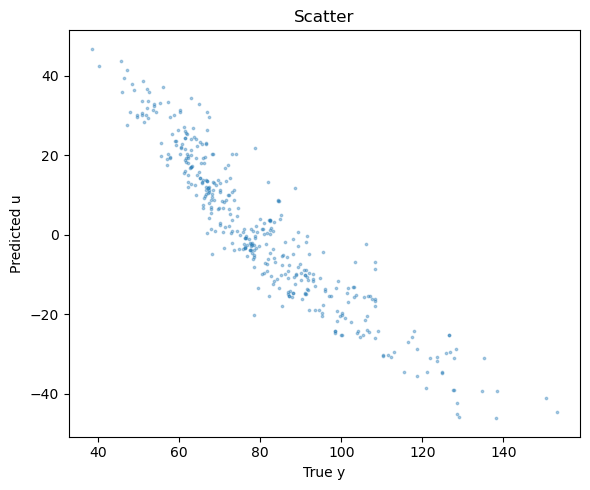

In [34]:
Theta_full_v_rv_mean_final = build_theta_from_model(
    X_final_test,
    sparse_result_v_rv_mean_final,
    param_names,
)

Theta_full_scaled_v_rv_mean_final = (
    sparse_result_v_rv_mean_final["scaler"].transform(
        Theta_full_v_rv_mean_final
    )
)

Theta_scaled_v_rv_mean_final = (
    Theta_full_scaled_v_rv_mean_final[
        :,
        sparse_result_v_rv_mean_final["active_indices"]
    ]
)

u_v_rv_mean_final_test = visualize_sparse_prediction(
    Theta_scaled_v_rv_mean_final,
    y_v_rv_mean_final_test,
    "../results/sparse_result_v_rv_mean_final.pkl",
)

### Feature Importance Evaluation

In [11]:
Theta_v_lv_max_final, feature_names_v_lv_max_final = build_function_library(
    X_final_train,
    param_names
)

Theta_scaled_v_lv_max_final = (
    sparse_result_v_lv_max_final["scaler"].transform(
        Theta_v_lv_max_final
    )
)

cmi_v_lv_max_final = analyze_feature_importance(
    sparse_result_v_lv_max_final,
    Theta_scaled_v_lv_max_final,
    y_v_lv_max_final_train
)


===== Feature Importance (Leave-One-Out MI) =====

Feature                                           Coeff         ΔMI      MI(-f)
----------------------------------------------------------------------------------
Emax_lv                                         10.2507      0.6568      1.3702
log(Emax_rv)                                    -2.4363      0.2772      1.7498
Za_p                                            -2.1163      0.2313      1.7958
log(C_s)                                         0.8935      0.1421      1.8849
C_p*R_p                                          0.5048      0.1180      1.9091
C_p*Emax_lv                                      0.4289      0.0961      1.9309
C_s*R_s                                          0.4485      0.0950      1.9320
C_p*Emin_lv                                      0.4302      0.0933      1.9337
C_p^2                                            0.3447      0.0928      1.9342
C_p*R_s                                          0.4211      0.08

In [5]:
Theta_v_lv_min_final, feature_names_v_lv_min_final = build_function_library(
    X_final_train,
    param_names
)

Theta_scaled_v_lv_min_final = (
    sparse_result_v_lv_min_final["scaler"].transform(
        Theta_v_lv_min_final
    )
)

cmi_v_lv_min_final = analyze_feature_importance(
    sparse_result_v_lv_min_final,
    Theta_scaled_v_lv_min_final,
    y_v_lv_min_final_train
)


===== Feature Importance (Leave-One-Out MI) =====

Feature                                           Coeff         ΔMI      MI(-f)
----------------------------------------------------------------------------------
Emax_lv                                         13.7670      1.5412     -0.0080
Za_p*R_p                                        -0.9109      0.0341      1.4991
----------------------------------------------------------------------------------
Full model MI : 1.533232


In [6]:
Theta_v_rv_max_final, feature_names_v_rv_max_final = build_function_library(
    X_final_train,
    param_names
)

Theta_scaled_v_rv_max_final = (
    sparse_result_v_rv_max_final["scaler"].transform(
        Theta_v_rv_max_final
    )
)

cmi_v_rv_max_final = analyze_feature_importance(
    sparse_result_v_rv_max_final,
    Theta_scaled_v_rv_max_final,
    y_v_rv_max_final_train
)


===== Feature Importance (Leave-One-Out MI) =====

Feature                                           Coeff         ΔMI      MI(-f)
----------------------------------------------------------------------------------
R_p*Za_s                                         6.9354      0.5862      1.4842
Emax_rv*R_s                                     -6.6909      0.4279      1.6424
Za_p*Emax_lv                                     4.6349      0.4199      1.6505
C_p                                             -4.9681      0.4190      1.6514
C_s*R_s                                         -4.9806      0.2047      1.8657
log(Emax_rv)                                    -2.9314      0.1418      1.9286
log(C_p)                                        -1.7115      0.1055      1.9649
R_p*Emax_lv                                      1.4432      0.0879      1.9824
Emin_rv*Za_s                                    -0.8527      0.0867      1.9837
C_p*C_s                                         -0.7799      0.08

In [7]:
Theta_v_rv_min_final, feature_names_v_rv_min_final = build_function_library(
    X_final_train,
    param_names
)

Theta_scaled_v_rv_min_final = (
    sparse_result_v_rv_min_final["scaler"].transform(
        Theta_v_rv_min_final
    )
)

cmi_v_rv_min_final = analyze_feature_importance(
    sparse_result_v_rv_min_final,
    Theta_scaled_v_rv_min_final,
    y_v_rv_min_final_train
)


===== Feature Importance (Leave-One-Out MI) =====

Feature                                           Coeff         ΔMI      MI(-f)
----------------------------------------------------------------------------------
Emax_rv                                         15.8438      0.8761      0.6165
C_p                                              4.3827      0.3155      1.1771
Za_s                                            -2.1584      0.0776      1.4149
C_p*Za_s                                         0.8957      0.0436      1.4490
C_s^2                                            1.4058      0.0404      1.4522
Emin_rv^2                                        0.7019      0.0300      1.4626
Za_p*Emin_rv                                     0.4805      0.0246      1.4680
Emax_rv^2                                        1.0480      0.0214      1.4712
C_s*Emin_lv                                      0.6695      0.0081      1.4845
Emax_lv                                         -0.0851      0.00

In [8]:
Theta_v_lv_mean_final, feature_names_v_lv_mean_final = build_function_library(
    X_final_train,
    param_names
)

Theta_scaled_v_lv_mean_final = (
    sparse_result_v_lv_mean_final["scaler"].transform(
        Theta_v_lv_mean_final
    )
)

cmi_v_lv_mean_final = analyze_feature_importance(
    sparse_result_v_lv_mean_final,
    Theta_scaled_v_lv_mean_final,
    y_v_lv_mean_final_train
)


===== Feature Importance (Leave-One-Out MI) =====

Feature                                           Coeff         ΔMI      MI(-f)
----------------------------------------------------------------------------------
Emax_lv                                         10.5898      1.1785      0.8421
Emax_rv                                         -0.6341      0.1204      1.9002
Emin_rv*Za_s                                     0.5645      0.1031      1.9175
Za_p^2                                          -0.8740      0.0841      1.9365
Emin_rv*C_s                                      0.2336      0.0530      1.9676
log(Emin_lv)                                     0.2394      0.0483      1.9723
C_s*Za_s                                         0.6174      0.0412      1.9794
Emin_lv^2                                        0.1730      0.0408      1.9798
Za_s*Emin_lv                                     0.1168      0.0404      1.9802
R_p*Za_s                                         0.1677      0.03

In [9]:
Theta_v_rv_mean_final, feature_names_v_rv_mean_final = build_function_library(
    X_final_train,
    param_names
)

Theta_scaled_v_rv_mean_final = (
    sparse_result_v_rv_mean_final["scaler"].transform(
        Theta_v_rv_mean_final
    )
)

cmi_v_rv_mean_final = analyze_feature_importance(
    sparse_result_v_rv_mean_final,
    Theta_scaled_v_rv_mean_final,
    y_v_rv_mean_final_train
)


===== Feature Importance (Leave-One-Out MI) =====

Feature                                           Coeff         ΔMI      MI(-f)
----------------------------------------------------------------------------------
Emax_rv                                         16.1023      1.2036      0.7898
C_p^2                                            4.5461      0.4213      1.5721
R_p^2                                           -4.3163      0.3441      1.6493
R_s^2                                            4.2100      0.2938      1.6996
Emax_rv^2                                       -8.0086      0.2858      1.7076
Emax_rv*R_s                                      2.8859      0.1511      1.8423
log(C_s)                                         3.3623      0.1424      1.8510
log(Za_p)                                       -0.8143      0.1354      1.8580
Za_s^2                                           1.4652      0.1097      1.8837
C_p*Emin_rv                                      1.6213      0.10